# Sequencial  Workflow 

In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [2]:
#define class 
class BMI(TypedDict):
    weight: float
    height: float
    bmi: float 
    category : str 

In [3]:
#function calculate BMI 
def bmi_calculator(state: BMI) -> BMI:

    weight = state['weight']
    height = state['height']

    bmi = weight / (height **2 )

    #upate state 

    state['bmi'] = round(bmi, 2)

    return state



In [4]:
def bmi_cat(state: BMI) -> BMI:
    bmi = state['bmi']

    if bmi < 18.5 :
        state["category"] = 'Underweight'
    elif 18.5 <= bmi < 25 :
        state["category"] = 'Normal weight'
    elif 25 <= bmi < 30 :
        state["category"] = 'Overweight'
    else :
        state["category"] = 'Obesity'
    return state

In [5]:
#define graph

graph = StateGraph(BMI)

#define nodes

graph.add_node("Calculate BMI",bmi_calculator)
graph.add_node("Category " , bmi_cat)

#define edges 

graph.add_edge(START,"Calculate BMI")
graph.add_edge("Calculate BMI","Category ")
graph.add_edge("Category ",END)

#define complile 
workflow = graph.compile()

In [6]:
# execute workflow

initial_State = {"weight": 70.0, "height": 1.75}

final_State  = workflow.invoke(initial_State)

print(final_State)

{'weight': 70.0, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


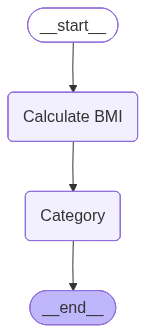

In [7]:
#visualize workflow
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())

# LLM Workflow

In [8]:
import os 
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint , ChatHuggingFace


In [9]:
#load environment 
load_dotenv()

True

In [10]:
#check token 
token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
if not token:
    print("Error: HUGGINGFACEHUB_API_TOKEN is not set in the .env file.")
else:
    print("Done")

Done


In [11]:
#  Setup the Endpoint
repo_id = "meta-llama/Llama-3.1-8B-Instruct"

llm_H = HuggingFaceEndpoint(
    repo_id=repo_id,
    task="text-generation",
    max_new_tokens=512,
    temperature=0.7,
    huggingfacehub_api_token=token,
)

h:\Projects\ai agent\ai-agents-LangGraph\agentvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
#  Wrap it in ChatHuggingFace (This handles the "conversational" format for you)
model = ChatHuggingFace(llm=llm_H)

In [13]:
#state 

class LLMstate(TypedDict):
    question : str 
    answer : str 

In [14]:
def llm_ans(state : LLMstate) -> LLMstate:
    question = state['question']
    prompt = f"Answer the question : {question}"
    answer  = model.invoke(prompt).content
    state['answer'] = answer
    return state

In [15]:
# graph 

graph = StateGraph(LLMstate)
# nodes 
graph.add_node("LLM_ans" , llm_ans)
# edges 
graph.add_edge(START,"LLM_ans")
graph.add_edge("LLM_ans",END)
# complile 
workflow = graph.compile()

In [16]:
# execute workflow

initial_state = {"question": "What is the capital of France?"}
final_State = workflow.invoke(initial_state)
print(final_State['answer'])

The capital of France is Paris.


# Prompt Chaining Workflow

In [17]:
class BlogState(TypedDict):
    title : str 
    content : str 
    outline: str 
    evaluation  : str

In [18]:
def generate_outline(state : BlogState) -> BlogState:
    title = state['title']
    prompt = f"Generate an outline for a blog post with the title : {title}"
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

In [19]:
def generate_blog(state : BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f"Generate a blog have title {title} post based on the following outline : {outline}"
    content = model.invoke(prompt).content
    state['content'] = content
    return state

In [20]:
def evaluate_blog(state: BlogState) -> BlogState:
    title = state['title']
    content = state['content']
    
    prompt = f"Evaluate the quality of the following blog post content: {content} having title {title}"
    evaluation = model.invoke(prompt).content  # generate evaluation
    state['evaluation'] = evaluation  # add to state
    
    return state

In [21]:
#graph 
graph = StateGraph(BlogState)
#nodes 
graph.add_node("Generate Outline", generate_outline)
graph.add_node("Generate Blog", generate_blog)
graph.add_node("Evaluate Blog", evaluate_blog)
#edges  
graph.add_edge(START , "Generate Outline")
graph.add_edge("Generate Outline" , "Generate Blog")
graph.add_edge("Generate Blog" , "Evaluate Blog")
graph.add_edge("Evaluate Blog" , END)
#compile 
workflow = graph.compile()

In [22]:
initial_state_gb = {"title": "The Benefits of AI in Healthcare"}
fs_gb = workflow.invoke(initial_state_gb)
print(fs_gb)

{'title': 'The Benefits of AI in Healthcare', 'content': "**The Benefits of AI in Healthcare**\n\nThe healthcare industry is on the cusp of a revolution, driven by the rapid advancement of artificial intelligence (AI) technologies. As the global population ages and healthcare systems grapple with increasing demands and constraints, innovation is more crucial than ever. In this blog post, we'll explore the benefits of AI in healthcare, from improved diagnosis and treatment to enhanced patient experience, cost reduction, and data-driven insights.\n\n**I. Introduction**\n\nThe current state of healthcare is marked by inefficiencies, high costs, and inconsistent outcomes. Patients often face long wait times, delayed diagnoses, and fragmented care. Healthcare providers struggle to keep pace with the ever-growing demands of an aging population, while also navigating complex regulatory environments and managing limited resources. Amidst this backdrop, AI emerges as a game-changer, poised to t

In [23]:
print(fs_gb.keys())

dict_keys(['title', 'content', 'outline', 'evaluation'])


In [24]:
print(fs_gb['outline'])

**Title:** The Benefits of AI in Healthcare

**I. Introduction**

* Brief overview of the current state of healthcare and the need for innovation
* Explanation of the role of AI in healthcare and its growing importance
* Thesis statement: AI has the potential to revolutionize healthcare by improving patient outcomes, reducing costs, and enhancing the overall patient experience.

**II. Improved Diagnosis and Treatment**

* Overview of AI's ability to analyze large amounts of data and identify patterns
* Discussion of AI-powered diagnostic tools, such as deep learning algorithms and natural language processing
* Examples of AI-assisted diagnosis and treatment in various medical fields (e.g., cancer, cardiovascular disease)

**III. Enhanced Patient Experience**

* Explanation of how AI can help personalize patient care through predictive analytics and real-time monitoring
* Discussion of AI-powered chatbots and virtual assistants that can help patients navigate the healthcare system
* Exa

In [25]:
print(fs_gb['evaluation'])

**Quality Evaluation:**

Overall, the quality of this blog post content is high. The author has provided a well-structured and informative article that effectively explores the benefits of AI in healthcare. Here are some strengths and weaknesses:

**Strengths:**

1. **Clear structure and organization**: The post is divided into clear sections, making it easy to follow and understand.
2. **Engaging introduction**: The introduction effectively sets the stage for the rest of the article and highlights the importance of AI in healthcare.
3. **Relevant examples and case studies**: The author provides concrete examples of how AI is being used in healthcare, such as cancer care and patient engagement.
4. **Thorough explanation of AI benefits**: The post provides a comprehensive overview of the benefits of AI in healthcare, including improved diagnosis and treatment, enhanced patient experience, and cost reduction.
5. **Use of technical terms and acronyms**: The author uses technical terms and

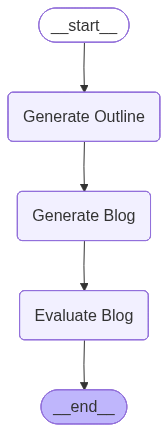

In [26]:
#visualize workflow
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())